# Fashion MNIST classification (Keras) with CNNs

## Libraries and constants

In [ ]:
import gc
import os

os.environ["KERAS_BACKEND"] = "torch"
import functools

import keras
import keras_tuner as kt
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from sklearn.metrics import ConfusionMatrixDisplay, classification_report, confusion_matrix
from torch.utils.data import DataLoader, Dataset, random_split
from utils import plot_loss_acc_per_ep, seed_everything

In [3]:
# --- CONSTANTS ---
RANDOM_SEED = 42

# --- SEEDING FUNCTIONALITY ---
rng = seed_everything(RANDOM_SEED)

# for num_workers > 0 in PyTorch DataLoader, each worker will inherit the exact same random state from the main process
# This means every worker will generate the exact same "random" data augmentations. We fix this using worker_init_fn
torch_gen = torch.Generator()
torch_gen.manual_seed(RANDOM_SEED)

This is a continuation of [module 12](https://github.com/jackyurchiksparrow/GO_IT_courses/blob/main/goit-ds-hw-12/main.ipynb), so the EDA is expected to have been done there.

## Data import

In [4]:
(X_train, y_train), (X_test, y_test) = keras.datasets.fashion_mnist.load_data()

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


### Data representation, data split

In [5]:
class FashionMNISTDataset(Dataset):
    def __init__(self, data: np.ndarray, targets: np.ndarray):
        self.data = torch.from_numpy(data).clone().float()      # pixels to floats to be able to normalize later
        self.targets = torch.from_numpy(targets).clone().int()  # class labels are integers (0-9)

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        img, target = self.data[idx], self.targets[idx]
        return img, target

In [6]:
X_train_writable = X_train.copy()
y_train_writable = y_train.copy()

X_test_writable = X_test.copy()
y_test_writable = y_test.copy()

In [7]:
full_train_ds  = FashionMNISTDataset(X_train_writable, y_train_writable)
test_ds  = FashionMNISTDataset(X_test_writable, y_test_writable)

# Split train into train/validation (90/10)
train_size = int(0.9 * len(X_train))
val_size = len(full_train_ds) - train_size

train_ds, valid_ds = random_split(
    dataset=full_train_ds,
    lengths=[train_size, val_size],
    generator=torch.Generator().manual_seed(RANDOM_SEED),
)

In [8]:
print(f"Train: {len(train_ds)}, Validation: {len(valid_ds)}, Test: {len(test_ds)}")

Train: 54000, Validation: 6000, Test: 10000


## Creating and testing loaders

In [9]:
train_loader = DataLoader(train_ds, batch_size=1024, shuffle=True, generator=torch_gen)
valid_loader = DataLoader(valid_ds, batch_size=1024, shuffle=False)
test_loader = DataLoader(test_ds, batch_size=1024, shuffle=False)

In [10]:
# DataLoaders testing
images_batch, targets_batch = next(iter(train_loader))

print("Images batch shape :", images_batch.shape)
print("Targets batch shape:", targets_batch.shape)
print("Images data type   :", images_batch.dtype)
print("Targets data type  :", targets_batch.dtype)
print("Targets in batch   :", targets_batch)

Images batch shape : torch.Size([1024, 28, 28])
Targets batch shape: torch.Size([1024])
Images data type   : torch.float32
Targets data type  : torch.int32
Targets in batch   : tensor([9, 3, 3,  ..., 3, 6, 6], dtype=torch.int32)


## Data normalization

In [ ]:
# Calculate the whole dataset's mean and std in batches (not needed for such a small dataset though)
n = 0; s = 0.0; ss = 0.0
for x, _ in train_loader:
    s  += x.sum().item()
    ss += (x**2).sum().item()
    n  += x.numel()

mean_ds = s / n
std_ds  = (ss/n - mean_ds**2) ** 0.5
variance_ds = std_ds ** 2

# Hardcode the stats into Keras
normalizer = keras.layers.Normalization(
    axis=None,
    mean=mean_ds,
    variance=variance_ds,
)

## Task 1

### Model architecting

Reference table:

| Year | Model                    | Total Params | FC-head Params | % in FC head | Typical block                                               | Conv layers | ImageNet acc (top 1) | ImageNet acc (top 5) |
| ---- | ------------------------ | ------------ | -------------- | ------------ | ----------------------------------------------------------- | ----------- | -------------------- | -------------------- |
| 1998 | LeNet-5                  | ~61,700      | ~59,100        | ~96%         | conv -> tanh -> avgpool                                     | 2           | ~99.0 (MNIST)        | —                    |
| 2012 | AlexNet                  | ~61,100,000  | ~58,600,000    | ~96%         | conv -> ReLU -> maxpool (LRN early)                         | 5           | 56.5                 | 79.1                 |
| 2014 | VGG-16                   | ~138,400,000 | ~123,600,000   | ~89%         | [conv3x3 -> ReLU] x2-3 -> maxpool                           | 13          | 71.6                 | 90.4                 |
| 2014 | VGG-19                   | ~143,700,000 | ~123,600,000   | ~86%         | [conv3x3 -> ReLU] x2-4 -> maxpool                           | 16          | 72.4                 | 90.9                 |
| 2015 | ResNet-18                | ~11,700,000  | ~513,000       | ~4%          | [conv3x3 -> BN -> ReLU -> conv3x3 -> BN] + skip -> ReLU     | 20          | 69.8                 | 89.1                 |
| 2015 | ResNet-34                | ~21,800,000  | ~513,000       | ~2%          | [conv3x3 -> BN -> ReLU -> conv3x3 -> BN] + skip -> ReLU     | 36          | 73.3                 | 91.4                 |

The first question is *what's the priority*.

It is **accuracy**.

*How many convolutions do I need* for best accuracy **at least**? Because we want the most efficient model.

Once we establish that, we will be assessing the model's performance empirically and adjust.

**Contemplation**: `Le-Net` is the simplest option, but its 2 layers might underperform, although it was specifically designed for datasets like this, namely numerical MNIST. The next models by architectural simplicity are `AlexNet` with 5 convolutions, `VGG` (13-16 convolutions) and `ResNet` (20 convolutions). `ResNet` is the most modern among them. Its accuracy is on point. We are going to use it as a benchmark and build a teeny-tiny version of it. The typical block in the architecture is `[conv3x3 -> BN -> ReLU -> conv3x3 -> BN] + skip -> ReLU`. Given the complexity of the data, we won't need skip connections. The number of convolutions for such datasets shouldn't be too far from `Le-Net` then, say 4-10. If this under-/overfits empirically, we will be increasing/reducing them further. The typical block structure in `VGG` is `[conv3x3 -> ReLU] x2-3 -> maxpool`.

In [ ]:
def cnn_block(n, activation_type="relu"):
    """Creates a sequential block consisting of Conv2D -> BatchNorm -> Activation."""
    return keras.Sequential([
        keras.layers.Conv2D(
            filters=n,
            kernel_size=(3, 3),
            strides=(1, 1),
            padding="valid",  # padding=0
            use_bias=False,     # no use in bias before BatchNorm
            activation=None,    # no use in activation before BatchNorm
        ),
        keras.layers.BatchNormalization(),
        keras.layers.Activation(activation_type),
    ])

def build_model(n, num_classes: int = 10, activation_type: str = "relu"):
    # 1. Define Input. Shape: (28,28,1) - grayscale
    inputs = keras.Input(shape=(28, 28, 1))

    # 2. Normalization Layer. Shape after: (28,28)
    x = keras.layers.Normalization()(inputs)

    # 3. First CNN block. Shape after: (n,26,26)
    x = cnn_block(n, activation_type)(x)

    # 4. Max Pooling. Shape after: (n,13,13)
    x = keras.layers.MaxPooling2D(pool_size=(2, 2))(x)

    # 5. Second CNN block. Shape after: (2n,11,11)
    x = cnn_block(2 * n, activation_type)(x)

    # 6. Third CNN block. Shape after: (4n,9,9)
    x = cnn_block(4 * n, activation_type)(x)

    # 7. Fourth CNN block. Shape after: (6n,7,7)
    x = cnn_block(6 * n, activation_type)(x)

    # 8. Flatten. Shape after: (1, 6nx7x7)
    x = keras.layers.Flatten()(x)

    # 9. Dense Classification Layer
    outputs = keras.layers.Dense(units=num_classes, activation="softmax")(x)

    # Construct the final model
    model = keras.Model(inputs=inputs, outputs=outputs)
    return model

In [ ]:
model = build_model(n=32, num_classes=10, activation_type="relu")
model.summary()

Model: "functional_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ normalization_1 (Normalization) │ (None, 28, 28, 1)      │             3 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential (Sequential)         │ (None, 26, 26, 32)     │           416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential_1 (Sequential)       │ (None, 11, 11, 64)     │        18,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential_2 (Sequential)       │ (None, 9, 9, 128)      │        74,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential_3 (Sequential)       │ (None, 7, 7, 192)      │       221,952 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 9408)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 10)             │        94,090 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 409,389 (1.56 MB)

 Trainable params: 408,554 (1.56 MB)

 Non-trainable params: 835 (3.26 KB)

The last fully-connected layer is `94,090` params for $n=32$. which is `23%` of all parameters, not critical given the reference table's.

This id what I picked up on the web: "The creators of ResNet (and a slightly earlier network called Network In Network) realized flattening was a massive waste of parameters that caused severe overfitting. Instead of flattening, they introduced Global Average Pooling (GAP)."

I am taking their approach.

In [ ]:
def build_model(n, num_classes: int = 10, activation_type: str = "relu"):
    # 1. Define Input. Shape: (28,28,1) - grayscale
    inputs = keras.Input(shape=(28, 28, 1))

    # 2. Normalization Layer. Shape after: (28,28)
    x = keras.layers.Normalization()(inputs)

    # 3. First CNN block. Shape after: (n,26,26)
    x = cnn_block(n, activation_type)(x)

    # 4. Max Pooling. Shape after: (n,13,13)
    x = keras.layers.MaxPooling2D(pool_size=(2, 2))(x)

    # 5. Second CNN block. Shape after: (2n,11,11)
    x = cnn_block(2 * n, activation_type)(x)

    # 6. Third CNN block. Shape after: (4n,9,9)
    x = cnn_block(4 * n, activation_type)(x)

    # 7. Fourth CNN block. Shape after: (6n,7,7)
    x = cnn_block(6 * n, activation_type)(x)

    # 8. Average pooling. Shape after: (6n)
    x = keras.layers.GlobalAveragePooling2D()(x)

    # 9. Dense Classification Layer
    outputs = keras.layers.Dense(units=num_classes, activation="softmax")(x)

    # Construct the final model
    model = keras.Model(inputs=inputs, outputs=outputs)
    return model

In [ ]:
model = build_model(n=32, num_classes=10, activation_type="relu")
model.summary()

Model: "functional_9"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_5 (InputLayer)      │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ normalization_2 (Normalization) │ (None, 28, 28, 1)      │             3 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential_4 (Sequential)       │ (None, 26, 26, 32)     │           416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential_5 (Sequential)       │ (None, 11, 11, 64)     │        18,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential_6 (Sequential)       │ (None, 9, 9, 128)      │        74,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential_7 (Sequential)       │ (None, 7, 7, 192)      │       221,952 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 192)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,930 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 317,229 (1.21 MB)

 Trainable params: 316,394 (1.21 MB)

 Non-trainable params: 835 (3.26 KB)

That's a massive parameter drop (48 times fewer params) in the final fully connected:

$\text{before: } 94,090 \quad \text{after: } 1,930$

### Training

In [ ]:
def build_rand_search_model(hp):
    # Define the hyperparameters
    activation = hp.Choice("activation", ["relu", "leaky_relu", "gelu", "silu"])        # 4 options
    units = hp.Choice("units", values=[8, 16, 32, 64])                                  # 4 options

    mdl = build_model(n=units, activation_type=activation)

    lr = hp.Choice("lr", values=[0.0001, 0.0005, 0.001, 0.005])                 # 4 options
    optimizer_name = hp.Choice("optimizer", values=["adam", "sgd", "rmsprop"])  # 3 options

    if optimizer_name == "adam":
        optimizer_obj = keras.optimizers.Adam(learning_rate=lr)
    elif optimizer_name == "sgd":
        optimizer_obj = keras.optimizers.SGD(learning_rate=lr, momentum=0.9)
    elif optimizer_name == "rmsprop":
        optimizer_obj = keras.optimizers.RMSprop(learning_rate=lr)

    mdl.compile(
        optimizer=optimizer_obj,
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"],
    )
    return mdl

In [11]:
def build_loaders(batch_size: int, shuffle: bool, generator):
    tr_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=shuffle, generator=generator)
    val_loader = DataLoader(valid_ds, batch_size=batch_size, shuffle=False)

    return tr_loader, val_loader

def debug_tuner(tuner):
    trial_list = []

    # Loop through all trials stored in the tuner's oracle
    for trial_id, trial in tuner.oracle.trials.items():
        row = {
            "trial_id": trial_id,
            "score": trial.score,  # This will be your val_accuracy or val_loss
        }
        # Unpack and add the specific hyperparameters chosen for this trial
        row.update(trial.hyperparameters.values)
        trial_list.append(row)

    # Convert to DataFrame
    df_results = pd.DataFrame(trial_list)

    # Sort them so the best-performing models are at the top
    # (Change ascending=True if you are optimizing for loss instead of accuracy)
    df_results = df_results.sort_values(by="score", ascending=False)

    # Display the neat table!
    return df_results

Total combinations: $4 \times 4 \times 4 \times 3 = 192$. Exploring $15$:

In [ ]:
keras.utils.set_random_seed(RANDOM_SEED)
torch_gen.manual_seed(RANDOM_SEED)
train_loader, valid_loader = build_loaders(batch_size=125, shuffle=True, generator=torch_gen)

tuner = kt.RandomSearch(
    build_rand_search_model,
    objective="val_accuracy",
    max_trials=15,
    directory="tuning",
    project_name="fashion_mnist",
    seed=RANDOM_SEED,
    overwrite=True,                             # start with fresh folder
)

tuner.search(
    x=train_loader,
    validation_data=valid_loader,
    epochs=10,
    callbacks=[keras.callbacks.EarlyStopping(monitor="val_loss", patience=5, verbose=1)],
    verbose=1,
    shuffle=False,
)

best_hp = tuner.get_best_hyperparameters(1)[0]
print(best_hp.values)

Trial 15 Complete [00h 02m 25s]
val_accuracy: 0.737666666507721

Best val_accuracy So Far: 0.9226666688919067
Total elapsed time: 00h 43m 04s
{'activation': 'gelu', 'units': 64, 'lr': 0.0005, 'optimizer': 'adam'}


In [ ]:
debug_tuner(tuner)

,trial_id,score,activation,units,lr,optimizer
13,13,0.922667,gelu,64,0.0005,adam
10,10,0.913833,relu,16,0.0010,adam
1,01,0.911000,silu,16,0.0010,adam
8,08,0.909500,silu,16,0.0005,rmsprop
3,03,0.895667,silu,8,0.0050,adam
12,12,0.888000,relu,8,0.0005,rmsprop
6,06,0.884000,relu,8,0.0010,rmsprop
2,02,0.880500,leaky_relu,8,0.0050,sgd
0,00,0.879500,gelu,8,0.0005,adam
11,11,0.878500,silu,8,0.0005,adam


New best score compared to the dense model from module 12: `0.922667`: `activation: gelu, units=64, optimizer=adam, lr=0.0005`.

Conclusions to shrink down the search space:
- higher units almost always result in higher score (removing `units=8`)
- `optimizer=sgd` didn't score enough, removed

Total combinations: $4 \times 3 \times 4 \times 2 = 96$. Exploring $15$:

In [ ]:
def build_rand_search_model(hp):
    # Define the hyperparameters
    activation = hp.Choice("activation", ["relu", "leaky_relu", "gelu", "silu"])        # 4 options
    units = hp.Choice("units", values=[16, 32, 64])                                     # 3 options

    mdl = build_model(n=units, activation_type=activation)

    lr = hp.Choice("lr", values=[0.0001, 0.0005, 0.001, 0.005])                 # 4 options
    optimizer_name = hp.Choice("optimizer", values=["adam", "rmsprop"])         # 2 options

    if optimizer_name == "adam":
        optimizer_obj = keras.optimizers.Adam(learning_rate=lr)
    elif optimizer_name == "rmsprop":
        optimizer_obj = keras.optimizers.RMSprop(learning_rate=lr)

    mdl.compile(
        optimizer=optimizer_obj,
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"],
    )
    return mdl

In [ ]:
keras.utils.set_random_seed(RANDOM_SEED)
torch_gen.manual_seed(RANDOM_SEED)
train_loader, valid_loader = build_loaders(batch_size=125, shuffle=True, generator=torch_gen)

tuner = kt.RandomSearch(
    build_rand_search_model,
    objective="val_accuracy",
    max_trials=15,
    directory="tuning",
    project_name="fashion_mnist",
    seed=RANDOM_SEED,
    overwrite=False,                            # continue the same search keeping track of old combinations
)

tuner.search(
    x=train_loader,
    validation_data=valid_loader,
    epochs=10,
    callbacks=[keras.callbacks.EarlyStopping(monitor="val_loss", patience=5, verbose=1)],
    verbose=1,
    shuffle=False,
)

best_hp = tuner.get_best_hyperparameters(1)[0]
print(best_hp.values)

Trial 15 Complete [00h 06m 27s]
val_accuracy: 0.9048333168029785

Best val_accuracy So Far: 0.9223333597183228
Total elapsed time: 00h 57m 23s
{'activation': 'gelu', 'units': 64, 'lr': 0.0005, 'optimizer': 'adam'}


In [ ]:
debug_tuner(tuner)

,trial_id,score,activation,units,lr,optimizer
12,12,0.922333,gelu,64,0.0005,adam
0,00,0.912333,gelu,16,0.0005,adam
9,09,0.911833,relu,32,0.0010,adam
1,01,0.910833,silu,32,0.0010,adam
4,04,0.910667,silu,32,0.0005,adam
3,03,0.909500,silu,16,0.0050,adam
8,08,0.909333,silu,16,0.0005,rmsprop
7,07,0.907667,silu,32,0.0005,rmsprop
5,05,0.906333,relu,16,0.0010,rmsprop
10,10,0.905333,silu,16,0.0005,adam


We've found the same best setup `activation: gelu, units=64, optimizer=adam, lr=0.0005`, which gave `0.92233` this time.

**In short**: I forgot to fix the seeds for convolutions AND tuner's init weights AND to set `overwrite=False`.

**Explanation**: The reason being is that keras-tuner reseeds nothing between trials. Every model's initial weights are drawn from wherever the backend RNG happens to be, which is wherever the previous trial left it. The id of this best trial is 12 (out of 14), previously it was 13.
The solution might be to change `torch.backends.cudnn.deterministic = True`, but it would significantly slow down the iterations.

The decided trade-off is to give up on the reproducibility in the context of the tuner and continue the comparison. However, adding additional seeds inside the tuner does help preserve the order of iteration therefore the initial weights bringing the final values closer together.

Conclusions to shrink down the search space further:
- optimizer: definitely `adam`
- removing `leaky_relu` since it wasn't among higher scores even with $n=32$
- exploring different learning rates (log-scale)

In [ ]:
def build_rand_search_model(hp):
    keras.utils.set_random_seed(RANDOM_SEED)   # resets python/numpy/torch-global -> weight init
    torch_gen.manual_seed(RANDOM_SEED)         # resets the DataLoader's shuffle stream -> data order

    # Define the hyperparameters
    activation = hp.Choice("activation", ["relu", "gelu", "silu"])        # 3 options
    units = hp.Choice("units", values=[16, 32, 64])                       # 3 options

    mdl = build_model(n=units, activation_type=activation)

    # hp.Float with sampling="log" for continuous logarithmic scaling
    lr = hp.Float("lr", min_value=1e-4, max_value=1e-2, sampling="log")

    optimizer_obj = keras.optimizers.Adam(learning_rate=lr)

    mdl.compile(
        optimizer=optimizer_obj,
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"],
    )
    return mdl

In [ ]:
keras.utils.set_random_seed(RANDOM_SEED)
torch_gen.manual_seed(RANDOM_SEED)
train_loader, valid_loader = build_loaders(batch_size=125, shuffle=True, generator=torch_gen)

tuner = kt.RandomSearch(
    build_rand_search_model,
    objective="val_accuracy",
    max_trials=15,
    directory="tuning",
    project_name="fashion_mnist",
    seed=RANDOM_SEED,
    overwrite=False,                            # continue the same search keeping track of old combinations
)

tuner.search(
    x=train_loader,
    validation_data=valid_loader,
    epochs=10,
    callbacks=[keras.callbacks.EarlyStopping(monitor="val_loss", patience=5, verbose=1)],
    verbose=1,
    shuffle=False,
)

best_hp = tuner.get_best_hyperparameters(1)[0]
print(best_hp.values)

Trial 15 Complete [00h 02m 45s]
val_accuracy: 0.9129999876022339

Best val_accuracy So Far: 0.9253333210945129
Total elapsed time: 00h 59m 22s
{'activation': 'relu', 'units': 64, 'lr': 0.000505466655750672}


In [ ]:
debug_tuner(tuner)

,trial_id,score,activation,units,lr
1,01,0.925333,relu,64,0.000505
3,03,0.921000,relu,64,0.001715
11,11,0.919833,gelu,32,0.003965
7,07,0.916500,gelu,32,0.000675
9,09,0.915000,silu,64,0.000444
6,06,0.913500,relu,32,0.007178
14,14,0.913000,silu,16,0.003829
8,08,0.908667,relu,16,0.003043
2,02,0.908500,gelu,16,0.000989
13,13,0.908500,gelu,16,0.000982


New best score: `0.925333`: `{'activation': 'relu', 'units': 64, 'lr': 0.000505466655750672}`

- Finally confirmed the more neurons, the higher the accuracy $\rightarrow$ sticking to `64`
- Choosing `relu` as the top scored setup and setting the `lr` fixed to its best value currently.

There's ultimately no reason to adjust batch_size as it will change the gradient dynamics, requiring further retuning of other parameters.

### Fine-tuning

The model after tuning:

In [ ]:
def build_model(lr: float = 0.000505466655750672):
    inputs = keras.Input(shape=(28, 28, 1))
    x = keras.layers.Normalization()(inputs)

    x = cnn_block(64, "relu")(x)
    x = keras.layers.MaxPooling2D(pool_size=(2, 2))(x)
    x = cnn_block(2 * 64, "relu")(x)
    x = cnn_block(4 * 64, "relu")(x)
    x = cnn_block(6 * 64, "relu")(x)
    x = keras.layers.GlobalAveragePooling2D()(x)

    outputs = keras.layers.Dense(units=10, activation="softmax")(x)

    model = keras.Model(inputs=inputs, outputs=outputs)

    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=lr),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"],
    )

    return model

tuned_model = build_model()
tuned_model.summary()

Model: "functional_9"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_5 (InputLayer)      │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ normalization_1 (Normalization) │ (None, 28, 28, 1)      │             3 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential_4 (Sequential)       │ (None, 26, 26, 64)     │           832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 13, 13, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential_5 (Sequential)       │ (None, 11, 11, 128)    │        74,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential_6 (Sequential)       │ (None, 9, 9, 256)      │       295,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential_7 (Sequential)       │ (None, 7, 7, 384)      │       886,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 384)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         3,850 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,261,133 (4.81 MB)

 Trainable params: 1,259,466 (4.80 MB)

 Non-trainable params: 1,667 (6.51 KB)

Exploring the training process of the best model:

In [ ]:
keras.utils.set_random_seed(RANDOM_SEED)
torch_gen.manual_seed(RANDOM_SEED)

train_loader, valid_loader = build_loaders(batch_size=125, shuffle=True, generator=torch_gen)
tuned_model = build_model()

history = tuned_model.fit(
    x=train_loader,
    validation_data=valid_loader,
    epochs=30,
    callbacks=[
        keras.callbacks.EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True, verbose=1),
    ],
    verbose=1,
    shuffle=False,
)

Epoch 1/30
432/432 ━━━━━━━━━━━━━━━━━━━━ 46s 107ms/step - accuracy: 0.8374 - loss: 0.4544 - val_accuracy: 0.8532 - val_loss: 0.3997
Epoch 2/30
432/432 ━━━━━━━━━━━━━━━━━━━━ 46s 106ms/step - accuracy: 0.8914 - loss: 0.3024 - val_accuracy: 0.8840 - val_loss: 0.3194
Epoch 3/30
432/432 ━━━━━━━━━━━━━━━━━━━━ 48s 112ms/step - accuracy: 0.9063 - loss: 0.2611 - val_accuracy: 0.8800 - val_loss: 0.3352
Epoch 4/30
432/432 ━━━━━━━━━━━━━━━━━━━━ 45s 105ms/step - accuracy: 0.9160 - loss: 0.2334 - val_accuracy: 0.8883 - val_loss: 0.3164
Epoch 5/30
432/432 ━━━━━━━━━━━━━━━━━━━━ 46s 105ms/step - accuracy: 0.9229 - loss: 0.2136 - val_accuracy: 0.8777 - val_loss: 0.3515
Epoch 6/30
432/432 ━━━━━━━━━━━━━━━━━━━━ 45s 104ms/step - accuracy: 0.9299 - loss: 0.1970 - val_accuracy: 0.9130 - val_loss: 0.2485
Epoch 7/30
432/432 ━━━━━━━━━━━━━━━━━━━━ 46s 106ms/step - accuracy: 0.9351 - loss: 0.1809 - val_accuracy: 0.9090 - val_loss: 0.2640
Epoch 8/30
432/432 ━━━━━━━━━━━━━━━━━━━━ 45s 105ms/step - accuracy: 0.9398 - loss: 0

Smoothed scores over epochs grouped by folds:
Epoch  0: train_loss=0.4544  val_loss=0.3997  train_acc=0.8374  val_acc=0.8532
Epoch  1: train_loss=0.3024  val_loss=0.3194  train_acc=0.8914  val_acc=0.8840
Epoch  2: train_loss=0.2611  val_loss=0.3352  train_acc=0.9063  val_acc=0.8800
Epoch  3: train_loss=0.2334  val_loss=0.3164  train_acc=0.9160  val_acc=0.8883
Epoch  4: train_loss=0.2136  val_loss=0.3515  train_acc=0.9229  val_acc=0.8777
Epoch  5: train_loss=0.1970  val_loss=0.2485  train_acc=0.9299  val_acc=0.9130
Epoch  6: train_loss=0.1809  val_loss=0.2640  train_acc=0.9351  val_acc=0.9090
Epoch  7: train_loss=0.1691  val_loss=0.2699  train_acc=0.9398  val_acc=0.9003
Epoch  8: train_loss=0.1553  val_loss=0.2776  train_acc=0.9444  val_acc=0.9032
Epoch  9: train_loss=0.1436  val_loss=0.2158  train_acc=0.9487  val_acc=0.9228
Epoch 10: train_loss=0.1313  val_loss=0.2538  train_acc=0.9535  val_acc=0.9120
Epoch 11: train_loss=0.1193  val_loss=0.2392  train_acc=0.9587  val_acc=0.9173
Epoch 

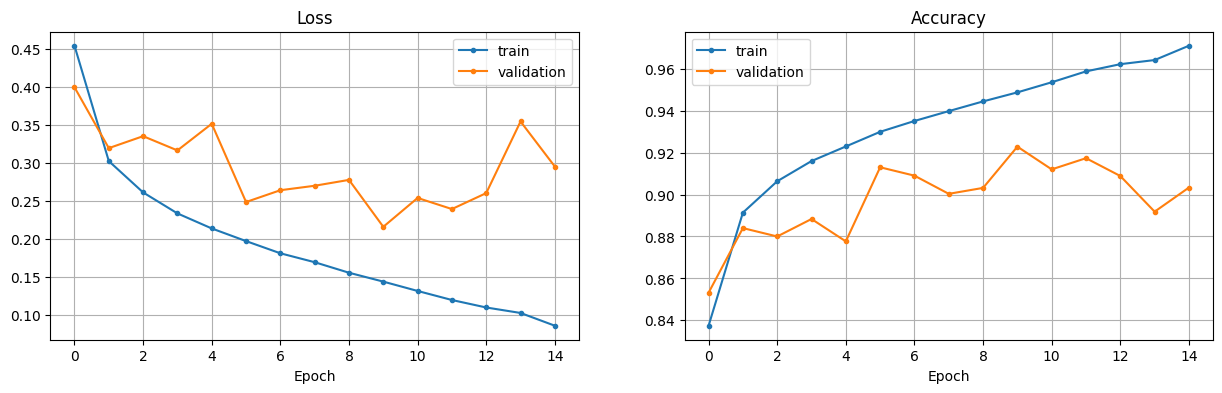

In [ ]:
plot_loss_acc_per_ep(history.history["loss"],     history.history["val_loss"],
                     history.history["accuracy"], history.history["val_accuracy"])

Best here: `Epoch[9]: train_loss=0.1436  val_loss=0.2158  train_acc=0.9487  val_acc=0.9228`.

Now, we need to establish the best base learning rate before applying the schedulers. To fine-tune this, we want to set a linear bracket that goes slightly below and slightly above the tuned `lr=0.000505`.

In [ ]:
def build_model():
    inputs = keras.Input(shape=(28, 28, 1))
    x = keras.layers.Normalization()(inputs)

    x = cnn_block(64, "relu")(x)
    x = keras.layers.MaxPooling2D(pool_size=(2, 2))(x)
    x = cnn_block(2 * 64, "relu")(x)
    x = cnn_block(4 * 64, "relu")(x)
    x = cnn_block(6 * 64, "relu")(x)
    x = keras.layers.GlobalAveragePooling2D()(x)

    outputs = keras.layers.Dense(units=10, activation="softmax")(x)

    model = keras.Model(inputs=inputs, outputs=outputs)
    return model

def build_rand_search_model(hp):
    keras.utils.set_random_seed(RANDOM_SEED)
    torch_gen.manual_seed(RANDOM_SEED)

    lr = hp.Float("lr", min_value=0.0003, max_value=0.0007, step=0.00005)   # 9 iterations (0.0007-0.0003)/0.00005 and 0.0003
    mdl = build_model()

    optimizer_obj = keras.optimizers.Adam(learning_rate=lr)

    mdl.compile(
        optimizer=optimizer_obj,
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"],
    )
    return mdl

In [ ]:
# Note: the seeds for con volutions were turned on from here onwards

In [ ]:
keras.utils.set_random_seed(RANDOM_SEED)
torch_gen.manual_seed(RANDOM_SEED)
train_loader, valid_loader = build_loaders(batch_size=125, shuffle=True, generator=torch_gen)

tuner = kt.RandomSearch(
    build_rand_search_model,
    objective="val_accuracy",
    max_trials=15,
    directory="fine_tuning",
    project_name="fashion_mnist",
    seed=RANDOM_SEED,
    overwrite=True,
)

tuner.search(
    x=train_loader,
    validation_data=valid_loader,
    epochs=10,
    callbacks=[keras.callbacks.EarlyStopping(monitor="val_loss", patience=5, verbose=1)],
    verbose=1,
    shuffle=False,
)

best_hp = tuner.get_best_hyperparameters(1)[0]
print(best_hp.values)

Trial 9 Complete [00h 09m 33s]
val_accuracy: 0.925000011920929

Best val_accuracy So Far: 0.9268333315849304
Total elapsed time: 01h 24m 03s
{'lr': 0.0006000000000000001}


In [ ]:
debug_tuner(tuner)

,trial_id,score,lr
7,07,0.926833,0.00060
5,05,0.926000,0.00050
8,08,0.925000,0.00035
4,04,0.923500,0.00065
0,00,0.923000,0.00055
3,03,0.921667,0.00040
2,02,0.920667,0.00045
1,01,0.918000,0.00030
6,06,0.917833,0.00070


New best: `{'lr': 0.0006000000000000001}, val_accuracy: 0.925000011920929`, assessing the plot to properly set up the schedulers:

The best model now:

In [ ]:
def build_model():
    inputs = keras.Input(shape=(28, 28, 1))
    x = keras.layers.Normalization()(inputs)

    x = cnn_block(64, "relu")(x)
    x = keras.layers.MaxPooling2D(pool_size=(2, 2))(x)
    x = cnn_block(2 * 64, "relu")(x)
    x = cnn_block(4 * 64, "relu")(x)
    x = cnn_block(6 * 64, "relu")(x)
    x = keras.layers.GlobalAveragePooling2D()(x)

    outputs = keras.layers.Dense(units=10, activation="softmax")(x)

    model = keras.Model(inputs=inputs, outputs=outputs)

    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=0.0006), # the newly discovered lr
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"],
    )

    return model

Observing the learning curves of the new best model:

In [ ]:
keras.utils.set_random_seed(RANDOM_SEED)
torch_gen.manual_seed(RANDOM_SEED)

train_loader, valid_loader = build_loaders(batch_size=125, shuffle=True, generator=torch_gen)
tuned_model = build_model()

history = tuned_model.fit(
    x=train_loader,
    validation_data=valid_loader,
    epochs=30,
    callbacks=[
        keras.callbacks.EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True, verbose=1),
    ],
    verbose=1,
    shuffle=False,
)

Epoch 1/30
432/432 ━━━━━━━━━━━━━━━━━━━━ 49s 113ms/step - accuracy: 0.8383 - loss: 0.4505 - val_accuracy: 0.8437 - val_loss: 0.4224
Epoch 2/30
432/432 ━━━━━━━━━━━━━━━━━━━━ 50s 116ms/step - accuracy: 0.8913 - loss: 0.3012 - val_accuracy: 0.8838 - val_loss: 0.3227
Epoch 3/30
432/432 ━━━━━━━━━━━━━━━━━━━━ 47s 108ms/step - accuracy: 0.9066 - loss: 0.2597 - val_accuracy: 0.8807 - val_loss: 0.3352
Epoch 4/30
432/432 ━━━━━━━━━━━━━━━━━━━━ 56s 130ms/step - accuracy: 0.9163 - loss: 0.2323 - val_accuracy: 0.8895 - val_loss: 0.3124
Epoch 5/30
432/432 ━━━━━━━━━━━━━━━━━━━━ 66s 153ms/step - accuracy: 0.9228 - loss: 0.2129 - val_accuracy: 0.8767 - val_loss: 0.3596
Epoch 6/30
432/432 ━━━━━━━━━━━━━━━━━━━━ 63s 146ms/step - accuracy: 0.9304 - loss: 0.1959 - val_accuracy: 0.9117 - val_loss: 0.2543
Epoch 7/30
432/432 ━━━━━━━━━━━━━━━━━━━━ 68s 157ms/step - accuracy: 0.9352 - loss: 0.1800 - val_accuracy: 0.9040 - val_loss: 0.2768
Epoch 8/30
432/432 ━━━━━━━━━━━━━━━━━━━━ 71s 163ms/step - accuracy: 0.9392 - loss: 0

Smoothed scores over epochs grouped by folds:
Epoch  0: train_loss=0.4505  val_loss=0.4224  train_acc=0.8383  val_acc=0.8437
Epoch  1: train_loss=0.3012  val_loss=0.3227  train_acc=0.8913  val_acc=0.8838
Epoch  2: train_loss=0.2597  val_loss=0.3352  train_acc=0.9066  val_acc=0.8807
Epoch  3: train_loss=0.2323  val_loss=0.3124  train_acc=0.9163  val_acc=0.8895
Epoch  4: train_loss=0.2129  val_loss=0.3596  train_acc=0.9228  val_acc=0.8767
Epoch  5: train_loss=0.1959  val_loss=0.2543  train_acc=0.9304  val_acc=0.9117
Epoch  6: train_loss=0.1800  val_loss=0.2768  train_acc=0.9352  val_acc=0.9040
Epoch  7: train_loss=0.1685  val_loss=0.2914  train_acc=0.9392  val_acc=0.8908
Epoch  8: train_loss=0.1546  val_loss=0.2492  train_acc=0.9442  val_acc=0.9130
Epoch  9: train_loss=0.1417  val_loss=0.2129  train_acc=0.9494  val_acc=0.9268
Epoch 10: train_loss=0.1301  val_loss=0.2678  train_acc=0.9532  val_acc=0.9047
Epoch 11: train_loss=0.1177  val_loss=0.2309  train_acc=0.9584  val_acc=0.9197
Epoch 

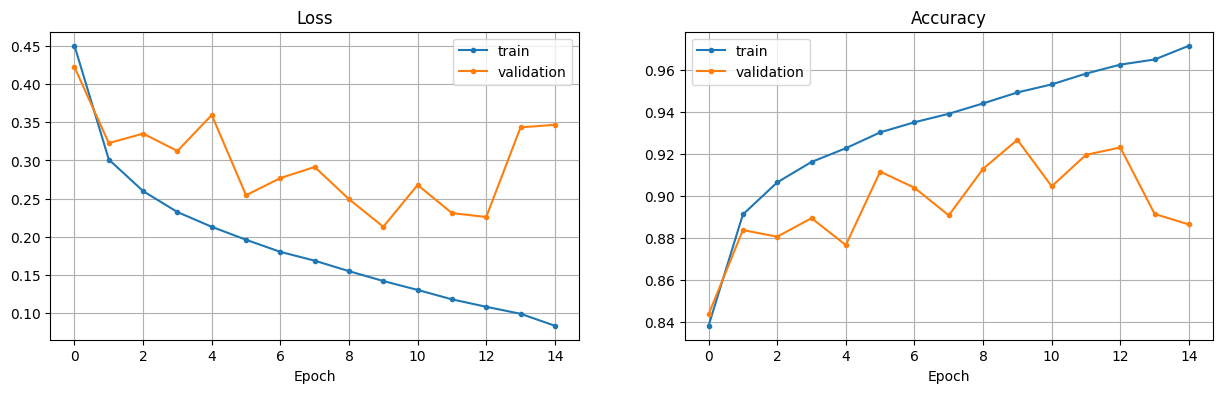

In [ ]:
plot_loss_acc_per_ep(history.history["loss"],     history.history["val_loss"],
                     history.history["accuracy"], history.history["val_accuracy"])

Epoch[9] is confirmed to be the most optimal. Saving the current best:

In [ ]:
tuned_model.save("fashion_mnist_best_before_ls_schedulers.keras")

#### Learning rate schedulers

In [ ]:
# redeclare for keras tuner
def build_model(lr):
    inputs = keras.Input(shape=(28, 28, 1))
    x = keras.layers.Normalization()(inputs)

    x = cnn_block(64, "relu")(x)
    x = keras.layers.MaxPooling2D(pool_size=(2, 2))(x)
    x = cnn_block(2 * 64, "relu")(x)
    x = cnn_block(4 * 64, "relu")(x)
    x = cnn_block(6 * 64, "relu")(x)
    x = keras.layers.GlobalAveragePooling2D()(x)

    outputs = keras.layers.Dense(units=10, activation="softmax")(x)

    model = keras.Model(inputs=inputs, outputs=outputs)

    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=lr),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"],
    )

    return model


def build_rand_search_model(hp, epochs):
    name = hp.Choice("scheduler", [
            "constant",          # baseline: flat 0.0006, for comparison
            "custom_stairs",     # custom staircase
            "exponential",       # smooth *0.9 per epoch
            "cosine",            # glide 0.0006 -> ~0 over the whole run
            "cosine_restarts",   # cosine, but periodically jumps back up (escapes basins)
            "inverse_time",      # 1/(1+decay*t)
            "piecewise",         # gentler staircase: /10 at epoch 10, /100 at 15
        ])

    base  = 0.0006
    steps = len(train_loader)          # batches per epoch
    S     = keras.optimizers.schedules

    if name == "custom_stairs":
        lr = S.PiecewiseConstantDecay(boundaries=[steps * 3, steps * 7, steps * 10],
                                      values=[base, 1e-4, 1e-5, 1e-6])
    elif name == "exponential":
        lr = S.ExponentialDecay(base, decay_steps=steps, decay_rate=0.9)
    elif name == "cosine":
        lr = S.CosineDecay(base, decay_steps=steps * epochs)
    elif name == "cosine_restarts":
        lr = S.CosineDecayRestarts(base, first_decay_steps=steps * 10)
    elif name == "inverse_time":
        lr = S.InverseTimeDecay(base, decay_steps=steps, decay_rate=0.5)
    elif name == "piecewise":
        lr = S.PiecewiseConstantDecay(boundaries=[steps * 10, steps * 15],
                                      values=[base, base * 0.1, base * 0.01])
    else: # "constant"
        lr = base

    model = build_model(lr=lr)
    return model

In [ ]:
keras.utils.set_random_seed(RANDOM_SEED)
torch_gen.manual_seed(RANDOM_SEED)
train_loader, valid_loader = build_loaders(batch_size=125, shuffle=True, generator=torch_gen)

sched_tuner = kt.GridSearch(
    functools.partial(build_rand_search_model, epochs=60),   # more epochs + functools to send an additional argument
    objective="val_accuracy",
    directory="fine_tuning_lr_schedulers",
    project_name="fashion_mnist_schedulers",
    seed=RANDOM_SEED,
    overwrite=True,
)
sched_tuner.search(x=train_loader, validation_data=valid_loader, epochs=60,   # more epochs
                   callbacks=[keras.callbacks.EarlyStopping(monitor="val_loss", patience=8, # more patience
                                                            restore_best_weights=True, verbose=1)],
                   verbose=1, shuffle=False)

Trial 7 Complete [00h 28m 48s]
val_accuracy: 0.9411666393280029

Best val_accuracy So Far: 0.9411666393280029
Total elapsed time: 03h 34m 24s


In [ ]:
debug_tuner(sched_tuner)

,trial_id,score,scheduler
6,0006,0.941167,piecewise
4,0004,0.935333,cosine_restarts
1,0001,0.934500,custom_stairs
2,0002,0.934167,exponential
5,0005,0.928833,inverse_time
0,0000,0.919500,constant
3,0003,0.918000,cosine


New absolute best validation accuracy score: `0.941167`, `scheduler=piecewise`.

### Best model and evaluation

In [ ]:
def build_final_model(base_lr: float, steps: int):
    inputs = keras.Input(shape=(28, 28, 1))
    x = keras.layers.Normalization()(inputs)

    x = cnn_block(64, "relu")(x)
    x = keras.layers.MaxPooling2D(pool_size=(2, 2))(x)
    x = cnn_block(2 * 64, "relu")(x)
    x = cnn_block(4 * 64, "relu")(x)
    x = cnn_block(6 * 64, "relu")(x)
    x = keras.layers.GlobalAveragePooling2D()(x)

    lr = keras.optimizers.schedules.PiecewiseConstantDecay(boundaries=[steps * 10, steps * 15], values=[base_lr, base_lr * 0.1, base_lr * 0.01])
    outputs = keras.layers.Dense(units=10, activation="softmax")(x)

    model = keras.Model(inputs=inputs, outputs=outputs)

    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=lr),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"],
    )

    return model

In [ ]:
keras.utils.set_random_seed(RANDOM_SEED)
torch_gen.manual_seed(RANDOM_SEED)

train_loader, valid_loader = build_loaders(batch_size=125, shuffle=True, generator=torch_gen)
steps = len(train_loader)
model = build_final_model(base_lr=0.0006, steps=steps)

history = model.fit(
    x=train_loader,
    validation_data=valid_loader,
    epochs=60,
    callbacks=[
        keras.callbacks.EarlyStopping(monitor="val_loss", patience=8, restore_best_weights=True, verbose=1),
    ],
    verbose=1,
    shuffle=False,
)

Epoch 1/60
432/432 ━━━━━━━━━━━━━━━━━━━━ 69s 160ms/step - accuracy: 0.8383 - loss: 0.4505 - val_accuracy: 0.8437 - val_loss: 0.4224
Epoch 2/60
432/432 ━━━━━━━━━━━━━━━━━━━━ 69s 159ms/step - accuracy: 0.8913 - loss: 0.3012 - val_accuracy: 0.8838 - val_loss: 0.3227
Epoch 3/60
432/432 ━━━━━━━━━━━━━━━━━━━━ 69s 159ms/step - accuracy: 0.9066 - loss: 0.2597 - val_accuracy: 0.8807 - val_loss: 0.3352
Epoch 4/60
432/432 ━━━━━━━━━━━━━━━━━━━━ 70s 163ms/step - accuracy: 0.9163 - loss: 0.2323 - val_accuracy: 0.8895 - val_loss: 0.3124
Epoch 5/60
432/432 ━━━━━━━━━━━━━━━━━━━━ 70s 161ms/step - accuracy: 0.9228 - loss: 0.2129 - val_accuracy: 0.8767 - val_loss: 0.3596
Epoch 6/60
432/432 ━━━━━━━━━━━━━━━━━━━━ 70s 162ms/step - accuracy: 0.9304 - loss: 0.1959 - val_accuracy: 0.9117 - val_loss: 0.2543
Epoch 7/60
432/432 ━━━━━━━━━━━━━━━━━━━━ 68s 158ms/step - accuracy: 0.9352 - loss: 0.1800 - val_accuracy: 0.9040 - val_loss: 0.2768
Epoch 8/60
432/432 ━━━━━━━━━━━━━━━━━━━━ 68s 158ms/step - accuracy: 0.9392 - loss: 0

Smoothed scores over epochs grouped by folds:
Epoch  0: train_loss=0.4505  val_loss=0.4224  train_acc=0.8383  val_acc=0.8437
Epoch  1: train_loss=0.3012  val_loss=0.3227  train_acc=0.8913  val_acc=0.8838
Epoch  2: train_loss=0.2597  val_loss=0.3352  train_acc=0.9066  val_acc=0.8807
Epoch  3: train_loss=0.2323  val_loss=0.3124  train_acc=0.9163  val_acc=0.8895
Epoch  4: train_loss=0.2129  val_loss=0.3596  train_acc=0.9228  val_acc=0.8767
Epoch  5: train_loss=0.1959  val_loss=0.2543  train_acc=0.9304  val_acc=0.9117
Epoch  6: train_loss=0.1800  val_loss=0.2768  train_acc=0.9352  val_acc=0.9040
Epoch  7: train_loss=0.1685  val_loss=0.2914  train_acc=0.9392  val_acc=0.8908
Epoch  8: train_loss=0.1546  val_loss=0.2492  train_acc=0.9442  val_acc=0.9130
Epoch  9: train_loss=0.1417  val_loss=0.2129  train_acc=0.9494  val_acc=0.9268
Epoch 10: train_loss=0.0945  val_loss=0.1816  train_acc=0.9699  val_acc=0.9375
Epoch 11: train_loss=0.0839  val_loss=0.1784  train_acc=0.9745  val_acc=0.9360
Epoch 

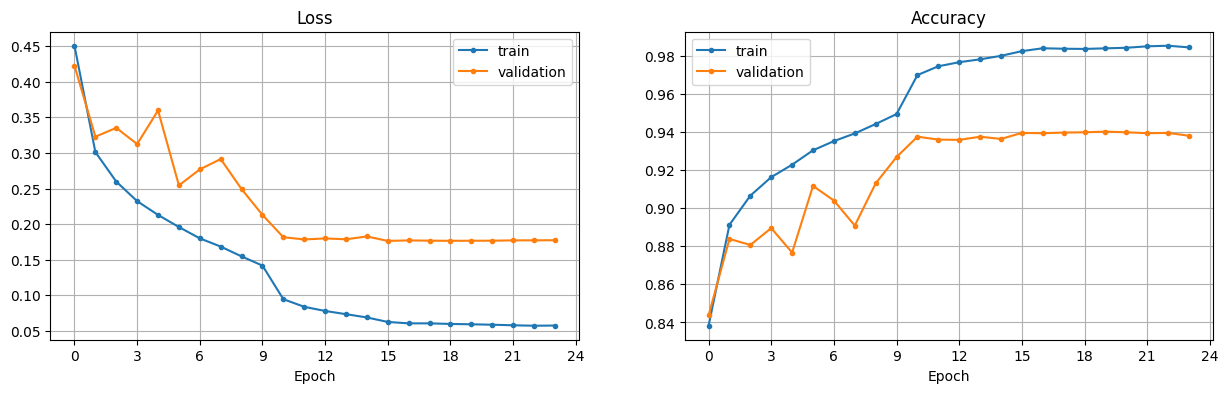

In [ ]:
plot_loss_acc_per_ep(history.history["loss"],     history.history["val_loss"],
                     history.history["accuracy"], history.history["val_accuracy"])

The most optimal: Epoch[15] - `train_loss=0.0626  val_loss=0.1764  train_acc=0.9824  val_acc=0.9395`

In [ ]:
# --- Save (Keras 3 native: architecture + weights + optimizer state in one file) ---
model.save("fashion_mnist_final_train.keras")

# --- Load ---
loaded = keras.models.load_model("fashion_mnist_final_train.keras")

Fit on full train first:

In [ ]:
keras.utils.set_random_seed(RANDOM_SEED)
torch_gen.manual_seed(RANDOM_SEED)

full_train_loader = DataLoader(full_train_ds, batch_size=125, shuffle=True, generator=torch_gen)
steps = len(full_train_loader)          # batches per epoch (for lr scheduler)
model = build_final_model(base_lr=0.0006, steps=steps)

history = model.fit(
    x=full_train_loader,
    epochs=16,
    verbose=1,
    shuffle=False,
)

Epoch 1/16
480/480 ━━━━━━━━━━━━━━━━━━━━ 25s 47ms/step - accuracy: 0.8399 - loss: 0.4425
Epoch 2/16
480/480 ━━━━━━━━━━━━━━━━━━━━ 22s 47ms/step - accuracy: 0.8949 - loss: 0.2935
Epoch 3/16
480/480 ━━━━━━━━━━━━━━━━━━━━ 27s 56ms/step - accuracy: 0.9086 - loss: 0.2554
Epoch 4/16
480/480 ━━━━━━━━━━━━━━━━━━━━ 22s 45ms/step - accuracy: 0.9170 - loss: 0.2288
Epoch 5/16
480/480 ━━━━━━━━━━━━━━━━━━━━ 22s 46ms/step - accuracy: 0.9250 - loss: 0.2090
Epoch 6/16
480/480 ━━━━━━━━━━━━━━━━━━━━ 22s 45ms/step - accuracy: 0.9317 - loss: 0.1910
Epoch 7/16
480/480 ━━━━━━━━━━━━━━━━━━━━ 23s 48ms/step - accuracy: 0.9354 - loss: 0.1785
Epoch 8/16
480/480 ━━━━━━━━━━━━━━━━━━━━ 22s 45ms/step - accuracy: 0.9416 - loss: 0.1638
Epoch 9/16
480/480 ━━━━━━━━━━━━━━━━━━━━ 22s 45ms/step - accuracy: 0.9458 - loss: 0.1501
Epoch 10/16
480/480 ━━━━━━━━━━━━━━━━━━━━ 21s 44ms/step - accuracy: 0.9512 - loss: 0.1372
Epoch 11/16
480/480 ━━━━━━━━━━━━━━━━━━━━ 22s 45ms/step - accuracy: 0.9693 - loss: 0.0931
Epoch 12/16
480/480 ━━━━━━━━━━

Smoothed scores over epochs grouped by folds:



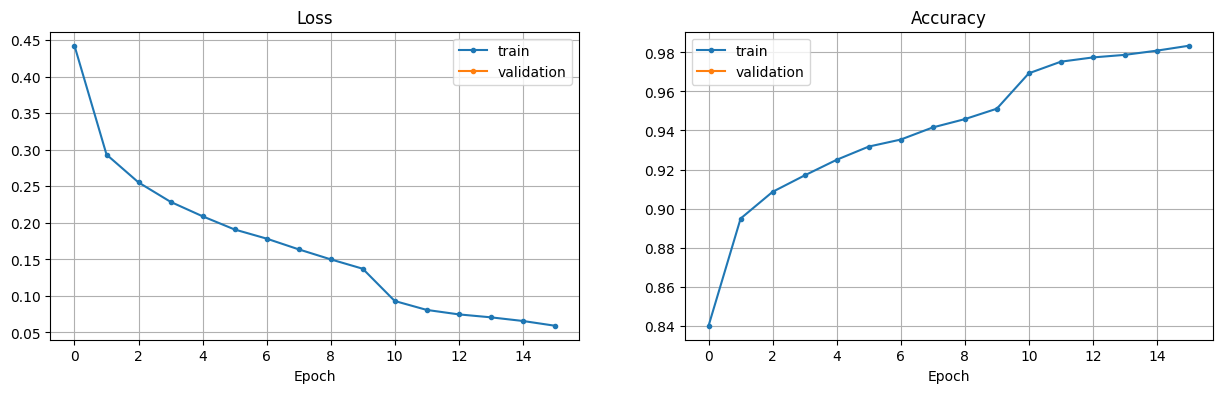

In [ ]:
plot_loss_acc_per_ep(history.history["loss"],     [],
                     history.history["accuracy"], [])

In [ ]:
test_loss, test_acc = model.evaluate(test_loader, verbose=1)

print("\n" + "="*40)
print(f"FINAL TEST ACCURACY: {test_acc * 100:.2f}%")
print(f"FINAL TEST LOSS:     {test_loss:.4f}")
print("="*40)

10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 68ms/step - accuracy: 0.9344 - loss: 0.1877

FINAL TEST ACCURACY: 93.44%
FINAL TEST LOSS:     0.1877


### Save/load the best model

In [ ]:
# --- Save (Keras 3 native: architecture + weights + optimizer state in one file) ---
model.save("fashion_mnist_final_test.keras")

# --- Load ---
loaded = keras.models.load_model("fashion_mnist_final_test.keras")

              precision    recall  f1-score   support

 T-shirt/top     0.8754    0.8850    0.8802      1000
     Trouser     0.9940    0.9870    0.9905      1000
    Pullover     0.9070    0.8970    0.9020      1000
       Dress     0.9370    0.9370    0.9370      1000
        Coat     0.9006    0.9150    0.9077      1000
      Sandal     0.9879    0.9830    0.9855      1000
       Shirt     0.8098    0.7960    0.8028      1000
     Sneaker     0.9665    0.9820    0.9742      1000
         Bag     0.9861    0.9910    0.9885      1000
  Ankle boot     0.9788    0.9710    0.9749      1000

    accuracy                         0.9344     10000
   macro avg     0.9343    0.9344    0.9343     10000
weighted avg     0.9343    0.9344    0.9343     10000



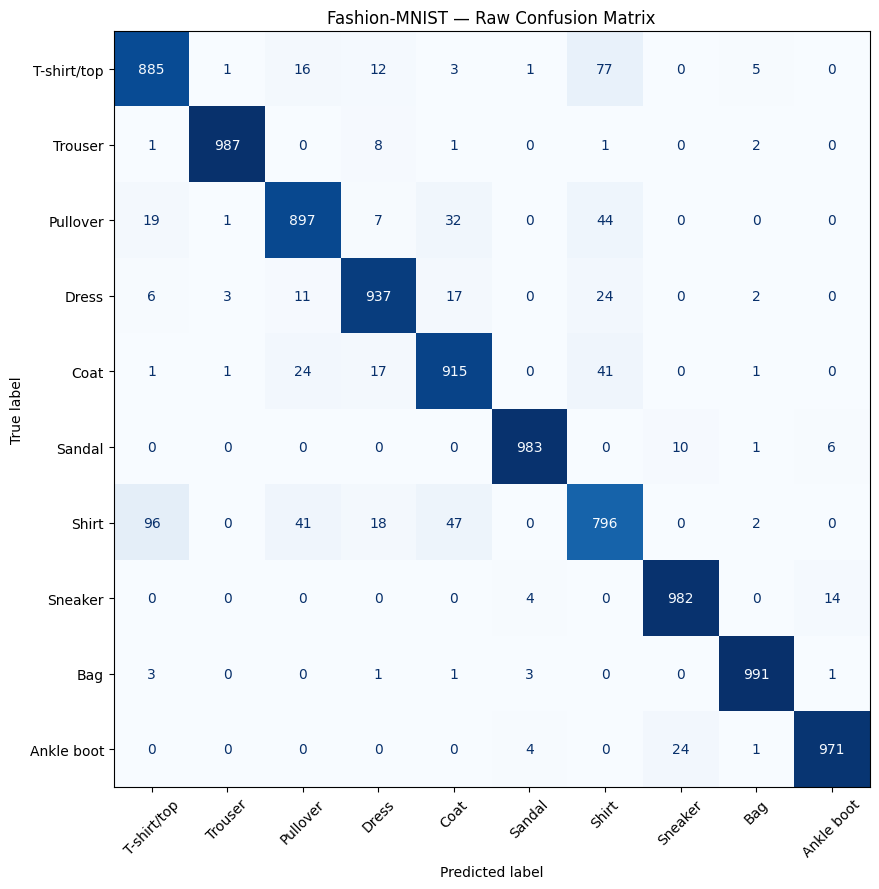

In [ ]:
CLASS_NAMES = ["T-shirt/top", "Trouser", "Pullover", "Dress", "Coat",
               "Sandal", "Shirt", "Sneaker", "Bag", "Ankle boot"]

# --- 1. Predictions + true labels out of the DataLoader ---
y_prob = model.predict(test_loader, verbose=0)          # (10000, 10) softmax probabilities
y_pred = y_prob.argmax(axis=1)                          # most probable class indices
y_true = np.concatenate([yb.numpy() for _, yb in test_loader])  # convert each y_batch from tensor to numpy and concatenate into 1D array

# --- 2. Per-class metrics ---
print(classification_report(y_true, y_pred, target_names=CLASS_NAMES, digits=4))

# --- 3. Confusion matrix ---
cm = confusion_matrix(y_true, y_pred)

fig, ax = plt.subplots(figsize=(9, 9))
ConfusionMatrixDisplay(cm, display_labels=CLASS_NAMES).plot(
    ax=ax,
    cmap="Blues",
    colorbar=False,
    values_format="d",  # integer format
    xticks_rotation=45,
)
ax.set_title("Fashion-MNIST — Raw Confusion Matrix")
plt.tight_layout()
plt.show()

### Conclusion

The best model has been established:

- Architecture:
```txt
Input -> normalizer -> cnn_block(64, "relu") -> MaxPooling2D -> cnn_block(2*64, "relu") -> cnn_block(4*64, "relu") -> cnn_block(6*64, "relu") -> GlobalAveragePooling2D -> Dense(10, "softmax")
```

- Params:
```txt
lr = 0.0006
batch_size = 125
optimizer = Adam
loss = sparse_categorical_crossentropy
scheduler = PiecewiseConstantDecay(boundaries=[steps * 10, steps * 15], values=[base_lr, base_lr * 0.1, base_lr * 0.01])
epoch = 16
```

- Scores:
```txt
Final test accuracy = `93.44%`
Final test loss = `0.1877`
```

The results are way better than without the convolutions, as was stated in the previous home task. The model still conflates `shirt` and `t-shirt`, `pullover`, `dress` a lot. I'd say we need larger photos to learn such details.

## Task 2

The task is to use transfer learning with **VGG16**. 






The strategy of transfer learning is determined by 2 main factors *together*: (1) **how much data we have per class** (small/medium/large), and (2) **how far our domain is from the data the model was pre-trained on**.

1. First off, **the domain**. And for the current domains, they are very far apart:
	- **Color (severe difference)**. **VGG16** expects colored images, we must use `keras.ops.repeat` to literally copy-paste the grayscale image three times just to match the model's expected input shape.
	- **Resolution/texture.**` ImageNet` is ~$500 \times 375$ photographs downsampled to $224 \times 224$, ours is $28 \times 28$ bilinearly upscaled to $96 \times 96$ (more on why $96$ below). Our images aren't capable to encode enough information (texture, colors etc.) to make the model discern the hardest classes properly: *T-shirt/top*, *Pullover*, *Coat*, *Shirt*. They all share the same upper-body silhouette. What separates them is **texture and fine detail**: sleeve length, collar, buttons, weave. That is precisely the information destroyed by low resolution.
	- **Composition**. `ImageNet` objects sit in scenes — backgrounds, occlusion, varied pose, scale, and lighting. Our `Fashion-MNIST` is a centered, size-normalized, uniformly-lit silhouette on pure black. 

**Intermediate conclusion**: the strategy of transfer learning doesn't prove to be best here due to the difference in domain. Depending on how much data we have (2), we might need to abandon it.

2. The second step is **Data quantity**. For a relative benchmark to compare against we look at `ImageNet`. For our case, the data is very large. `Fashion-MNIST` gives the network 4.7× more examples per class than `ImageNet` itself does:

| Dataset                | Total Images | Classes | Images per Class |
| :--------------------- | -----------: | ------: | ---------------: |
| `ImageNet` (ILSVRC-2012) |    1,281,167 |   1,000 |            1,281 |
| `Fashion-MNIST` (train)  |       60,000 |      10 |        **6,000** |

According to theoretical guidelines below, we ought to drop the transfer-learning strategy:
 
| Images per Class | Band       | Trainable budget it supports                                                  |
| :--------------- | :--------- | :---------------------------------------------------------------------------- |
| < 50             | very small | A head only. Explore few-shot methods additionally.                           |
| 50 – 500         | small      | A head, plus at most one block under heavy regularization.                    |
| 500 – 5,000      | medium     | A head plus the top block or two.                                             |
| > 5,000          | large      | Most of the network, if the domain justifies it. From scratch becomes viable. |

Based on the quantity, we are past the point of using transfer learning (> 5,000). Even if it does perform better, the trade-off in its speed and computational efficiency will likely be incomparable to the gained accuracy. And the training/tuning process becomes hard and long. Again, sticking to the task and proving it.

### Stage 1 - Feature extraction

In [12]:
IMG_SIZE = 96                               # the closest size to reshape the input to to keep up with the architecture

base = keras.applications.VGG16(
    weights="imagenet",                     # use pre-trained model
    include_top=False,                      # remove the head
    input_shape=(IMG_SIZE, IMG_SIZE, 3),    # expect the output as specified
)
base.trainable = False                      # freeze the base

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step


In [16]:
# --- ONCE: build the frozen extractor and run the data through it a single time ---
extractor = keras.Sequential([
    keras.layers.Input(shape=(28, 28)),                                       # current inputs are 28x28 first
    keras.layers.Reshape((28, 28, 1)),                                        # explicitly add the channel dimension (28,28) -> (28,28,1)
    keras.layers.Lambda(lambda t: keras.ops.repeat(t, 3, axis=-1)),           # repeat gray 3 times to resemble the 3 channel-format (RGB)
    keras.layers.Resizing(IMG_SIZE, IMG_SIZE, interpolation="bilinear"),      # resize into the expected minimum of 96x96
    keras.layers.Lambda(keras.applications.vgg16.preprocess_input),           # match VGG's scaling expectations
    base,                                                                     # frozen base
    keras.layers.GlobalAveragePooling2D(),                                    # flatten using GAP as in our custom architecture -> (512,)
])

def extract(loader):
    feats, labels = [], []
    for xb, yb in loader:                                                     # small batches here ONLY to survive memory (predict already enforces inference mode)
        feats.append(extractor.predict(xb, verbose=0))
        labels.append(np.asarray(yb))
    return np.concatenate(feats), np.concatenate(labels)

keras.utils.set_random_seed(RANDOM_SEED)
torch_gen.manual_seed(RANDOM_SEED)
train_loader, valid_loader = build_loaders(batch_size=1024, shuffle=True, generator=torch_gen)
Xtr, ytr = extract(train_loader)             # (54000, 512)
Xva, yva = extract(valid_loader)

# --- THEN: the tuner only ever sees a tiny dense head ---
def build_head(hp):
    inputs = keras.Input(shape=(512,))
    d  = hp.Float("dropout", 0.0, 0.3, step=0.1)
    lr = hp.Float("lr", 1e-4, 1e-2, sampling="log")
    name = hp.Choice("optimizer", ["adam", "sgd", "rmsprop"])
    opt = {"adam": keras.optimizers.Adam(lr),
           "sgd": keras.optimizers.SGD(lr, momentum=0.9),
           "rmsprop": keras.optimizers.RMSprop(lr)}[name]

    x = keras.layers.Dropout(d, seed=RANDOM_SEED)(inputs)                     # industry standard to regularize for large data per class (6000 images)
    outputs = keras.layers.Dense(10, activation="softmax")(x)
    model = keras.Model(inputs, outputs)
    model.compile(optimizer=opt, loss="sparse_categorical_crossentropy", metrics=["accuracy"])
    return model

In [17]:
keras.utils.set_random_seed(RANDOM_SEED)
torch_gen.manual_seed(RANDOM_SEED)

tuner = kt.RandomSearch(
    build_head,
    objective="val_accuracy",
    max_trials=15,
    directory="task_2_tuning",
    project_name="fashion_mnist",
    seed=RANDOM_SEED,
    overwrite=True,                            # new search
)


tuner.search(
    x=Xtr,
    y=ytr,
    validation_data=(Xva, yva),
    epochs=10,
    callbacks=[keras.callbacks.EarlyStopping(monitor="val_loss", patience=5, verbose=1)],
    verbose=1,
    shuffle=False,
)

best_hp = tuner.get_best_hyperparameters(1)[0]
print(best_hp.values)

Trial 15 Complete [00h 02m 31s]
val_accuracy: 0.8708333373069763

Best val_accuracy So Far: 0.8765000104904175
Total elapsed time: 00h 33m 46s
{'dropout': 0.2, 'lr': 0.00019528654576328537, 'optimizer': 'adam'}


In [18]:
debug_tuner(tuner)

,trial_id,score,dropout,lr,optimizer
12,12,0.876500,0.2,0.000195,adam
10,10,0.874833,0.0,0.000363,rmsprop
4,04,0.872667,0.2,0.000152,rmsprop
11,11,0.872500,0.1,0.000551,rmsprop
14,14,0.870833,0.2,0.000251,rmsprop
8,08,0.870500,0.0,0.000141,rmsprop
0,00,0.867500,0.1,0.000119,sgd
2,02,0.867000,0.1,0.000136,sgd
6,06,0.865167,0.0,0.000975,rmsprop
7,07,0.865000,0.1,0.000896,sgd


In [19]:
def build_head(hp):
    inputs = keras.Input(shape=(512,))
    d  = hp.Float("dropout", 0.0, 0.3, step=0.1)
    lr = hp.Float("lr", 1e-4, 1e-2, sampling="log")
    name = hp.Choice("optimizer", ["adam", "rmsprop"])
    opt = {"adam": keras.optimizers.Adam(lr),
           "rmsprop": keras.optimizers.RMSprop(lr)}[name]

    x = keras.layers.Dropout(d, seed=RANDOM_SEED)(inputs)                     # industry standard to regularize for large data per class (6000 images)
    outputs = keras.layers.Dense(10, activation="softmax")(x)
    model = keras.Model(inputs, outputs)
    model.compile(optimizer=opt, loss="sparse_categorical_crossentropy", metrics=["accuracy"])
    return model

In [22]:
keras.utils.set_random_seed(RANDOM_SEED)
torch_gen.manual_seed(RANDOM_SEED)

tuner = kt.RandomSearch(
    build_head,
    objective="val_accuracy",
    max_trials=15+15,
    directory="task_2_tuning",
    project_name="fashion_mnist",
    seed=RANDOM_SEED,
    overwrite=False,                            # continue search
)


tuner.search(
    x=Xtr,
    y=ytr,
    validation_data=(Xva, yva),
    epochs=10,
    callbacks=[keras.callbacks.EarlyStopping(monitor="val_loss", patience=5, verbose=1)],
    verbose=1,
    shuffle=False,
)

best_hp = tuner.get_best_hyperparameters(1)[0]
print(best_hp.values)

Trial 30 Complete [00h 02m 09s]
val_accuracy: 0.8650000095367432

Best val_accuracy So Far: 0.8765000104904175
Total elapsed time: 01h 09m 21s
{'dropout': 0.2, 'lr': 0.00019528654576328537, 'optimizer': 'adam'}


In [23]:
debug_tuner(tuner)

,trial_id,score,dropout,lr,optimizer
6,12,0.876500,0.2,0.000195,adam
15,15,0.875167,0.0,0.000624,adam
7,10,0.874833,0.0,0.000363,rmsprop
22,22,0.873833,0.0,0.000362,rmsprop
28,28,0.873500,0.1,0.000123,rmsprop
11,04,0.872667,0.2,0.000152,rmsprop
0,11,0.872500,0.1,0.000551,rmsprop
3,14,0.870833,0.2,0.000251,rmsprop
2,08,0.870500,0.0,0.000141,rmsprop
23,23,0.869667,0.2,0.000917,adam


fixed the dropout and Adam, increased LR,

In [25]:
def build_head(hp):
    inputs = keras.Input(shape=(512,))
    lr = hp.Float("lr", 1e-3, 1e-2, sampling="log") # lr increased

    x = keras.layers.Dropout(0.2, seed=RANDOM_SEED)(inputs)
    outputs = keras.layers.Dense(10, activation="softmax")(x)
    model = keras.Model(inputs, outputs)
    model.compile(optimizer=keras.optimizers.Adam(lr), loss="sparse_categorical_crossentropy", metrics=["accuracy"])
    return model

In [26]:
keras.utils.set_random_seed(RANDOM_SEED)
torch_gen.manual_seed(RANDOM_SEED)

tuner = kt.RandomSearch(
    build_head,
    objective="val_accuracy",
    max_trials=15+15+15,
    directory="task_2_tuning",
    project_name="fashion_mnist",
    seed=RANDOM_SEED,
    overwrite=False,                            # continue search
)


tuner.search(
    x=Xtr,
    y=ytr,
    validation_data=(Xva, yva),
    epochs=10,
    callbacks=[keras.callbacks.EarlyStopping(monitor="val_loss", patience=5, verbose=1)],
    verbose=1,
    shuffle=False,
)

best_hp = tuner.get_best_hyperparameters(1)[0]
print(best_hp.values)

Trial 45 Complete [00h 01m 52s]
val_accuracy: 0.8684999942779541

Best val_accuracy So Far: 0.8778333067893982
Total elapsed time: 01h 53m 40s
{'dropout': 0.2, 'lr': 0.0003243806953412315, 'optimizer': 'rmsprop'}


In [27]:
debug_tuner(tuner)

,trial_id,score,dropout,lr,optimizer
42,42,0.877833,0.2,0.000324,rmsprop
39,39,0.877500,0.1,0.000176,sgd
41,41,0.877167,0.0,0.000228,adam
37,37,0.877000,0.2,0.000255,sgd
17,12,0.876500,0.2,0.000195,adam
16,15,0.875167,0.0,0.000624,adam
19,10,0.874833,0.0,0.000363,rmsprop
7,22,0.873833,0.0,0.000362,rmsprop
43,43,0.873667,0.2,0.000507,adam
35,35,0.873500,0.1,0.000641,adam


In [28]:
def build_head(hp):
    inputs = keras.Input(shape=(512,))
    lr = hp.Float("lr", min_value=0.0003, max_value=0.0007, step=0.00005) # discrete lr - 9 iterations (0.0007-0.0003)/0.00005 and 0.0003

    x = keras.layers.Dropout(0.2, seed=RANDOM_SEED)(inputs)
    outputs = keras.layers.Dense(10, activation="softmax")(x)
    model = keras.Model(inputs, outputs)
    model.compile(optimizer=keras.optimizers.Adam(lr), loss="sparse_categorical_crossentropy", metrics=["accuracy"])
    return model

In [30]:
keras.utils.set_random_seed(RANDOM_SEED)
torch_gen.manual_seed(RANDOM_SEED)

tuner = kt.RandomSearch(
    build_head,
    objective="val_accuracy",
    max_trials=15+15+15+9,
    directory="task_2_tuning",
    project_name="fashion_mnist",
    seed=RANDOM_SEED,
    overwrite=False,                            # continue search
)

tuner.search(
    x=Xtr,
    y=ytr,
    validation_data=(Xva, yva),
    epochs=10,
    callbacks=[keras.callbacks.EarlyStopping(monitor="val_loss", patience=5, verbose=1)],
    verbose=1,
    shuffle=False,
)

best_hp = tuner.get_best_hyperparameters(1)[0]
print(best_hp.values)

Trial 54 Complete [00h 01m 54s]
val_accuracy: 0.8479999899864197

Best val_accuracy So Far: 0.8778333067893982
Total elapsed time: 02h 28m 43s
{'dropout': 0.2, 'lr': 0.0003243806953412315, 'optimizer': 'rmsprop'}


In [31]:
debug_tuner(tuner)

,trial_id,score,dropout,lr,optimizer
22,42,0.877833,0.2,0.000324,rmsprop
12,39,0.877500,0.1,0.000176,sgd
27,41,0.877167,0.0,0.000228,adam
21,37,0.877000,0.2,0.000255,sgd
29,12,0.876500,0.2,0.000195,adam
47,47,0.876333,0.0,0.000356,rmsprop
49,49,0.876333,0.1,0.000141,rmsprop
28,15,0.875167,0.0,0.000624,adam
31,10,0.874833,0.0,0.000363,rmsprop
48,48,0.874000,0.1,0.000504,rmsprop


### Fine-tuning

In [ ]:
def build_model(base):
  # 1. Unfreeze the top 4 layers of the base (Block 5)
  base.trainable = True
  for layer in base.layers[:-4]:
      layer.trainable = False

  # 2. Build the FULL end-to-end model
  inputs = keras.Input(shape=(28, 28))

  # Preprocessing (identical to your extractor)
  x = keras.layers.Reshape((28, 28, 1))(inputs)
  x = keras.layers.Lambda(lambda t: keras.ops.repeat(t, 3, axis=-1))(x)
  x = keras.layers.Resizing(IMG_SIZE, IMG_SIZE, interpolation="bilinear")(x)
  x = keras.layers.Lambda(keras.applications.vgg16.preprocess_input)(x)

  # Pass through the partially trainable base
  x = base(x)
  x = keras.layers.GlobalAveragePooling2D()(x)

  # Add your tuned head
  x = keras.layers.Dropout(0.2, seed=RANDOM_SEED)(x)
  outputs = keras.layers.Dense(10, activation="softmax")(x)

  model = keras.Model(inputs, outputs)
  return model


keras.utils.set_random_seed(RANDOM_SEED)
torch_gen.manual_seed(RANDOM_SEED)
# Reset seeds and clear previous Keras/PyTorch GPU state
keras.backend.clear_session()
gc.collect()
torch.cuda.empty_cache()

# 2. Re-instantiate a FRESH base model from ImageNet weights
fresh_base = keras.applications.VGG16(
    weights="imagenet",                     # use pre-trained model
    include_top=False,                      # remove the head
    input_shape=(IMG_SIZE, IMG_SIZE, 3),    # expect the output as specified
)
fresh_base.trainable = False                      # freeze the base


# Smaller batch size is needed here; backpropagating through VGG Block 5 uses much more VRAM, it crashes
train_loader, valid_loader = build_loaders(batch_size=16, shuffle=True, generator=torch_gen)

model = build_model(fresh_base)

# 3. Compile the end-to-end model
model.compile(
    optimizer=keras.optimizers.Adam(1e-5),     # Microscopic LR to prevent wrecking the pretrained weights
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)

history = model.fit(
    x=train_loader,
    validation_data=valid_loader,
    epochs=20,
    callbacks=[
        keras.callbacks.EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True, verbose=1),
    ],
    verbose=1,
    shuffle=False,
)

Epoch 1/20
3375/3375 ━━━━━━━━━━━━━━━━━━━━ 171s 51ms/step - accuracy: 0.8927 - loss: 0.3029 - val_accuracy: 0.9115 - val_loss: 0.2425
Epoch 2/20
3375/3375 ━━━━━━━━━━━━━━━━━━━━ 178s 53ms/step - accuracy: 0.9241 - loss: 0.2094 - val_accuracy: 0.9232 - val_loss: 0.2139
Epoch 3/20
3375/3375 ━━━━━━━━━━━━━━━━━━━━ 171s 51ms/step - accuracy: 0.9415 - loss: 0.1602 - val_accuracy: 0.9272 - val_loss: 0.2085
Epoch 4/20
3375/3375 ━━━━━━━━━━━━━━━━━━━━ 172s 51ms/step - accuracy: 0.9543 - loss: 0.1247 - val_accuracy: 0.9287 - val_loss: 0.2005
Epoch 5/20
3375/3375 ━━━━━━━━━━━━━━━━━━━━ 172s 51ms/step - accuracy: 0.9635 - loss: 0.0992 - val_accuracy: 0.9323 - val_loss: 0.2032
Epoch 6/20
3375/3375 ━━━━━━━━━━━━━━━━━━━━ 171s 51ms/step - accuracy: 0.9720 - loss: 0.0790 - val_accuracy: 0.9353 - val_loss: 0.2224
Epoch 7/20
3375/3375 ━━━━━━━━━━━━━━━━━━━━ 170s 50ms/step - accuracy: 0.9766 - loss: 0.0640 - val_accuracy: 0.9307 - val_loss: 0.2260
Epoch 8/20
3375/3375 ━━━━━━━━━━━━━━━━━━━━ 170s 51ms/step - accuracy: 

Smoothed scores over epochs grouped by folds:
Epoch  0: train_loss=0.3029  val_loss=0.2425  train_acc=0.8927  val_acc=0.9115
Epoch  1: train_loss=0.2094  val_loss=0.2139  train_acc=0.9241  val_acc=0.9232
Epoch  2: train_loss=0.1602  val_loss=0.2085  train_acc=0.9415  val_acc=0.9272
Epoch  3: train_loss=0.1247  val_loss=0.2005  train_acc=0.9543  val_acc=0.9287
Epoch  4: train_loss=0.0992  val_loss=0.2032  train_acc=0.9635  val_acc=0.9323
Epoch  5: train_loss=0.0790  val_loss=0.2224  train_acc=0.9720  val_acc=0.9353
Epoch  6: train_loss=0.0640  val_loss=0.2260  train_acc=0.9766  val_acc=0.9307
Epoch  7: train_loss=0.0517  val_loss=0.2229  train_acc=0.9819  val_acc=0.9378
Epoch  8: train_loss=0.0417  val_loss=0.2340  train_acc=0.9853  val_acc=0.9340



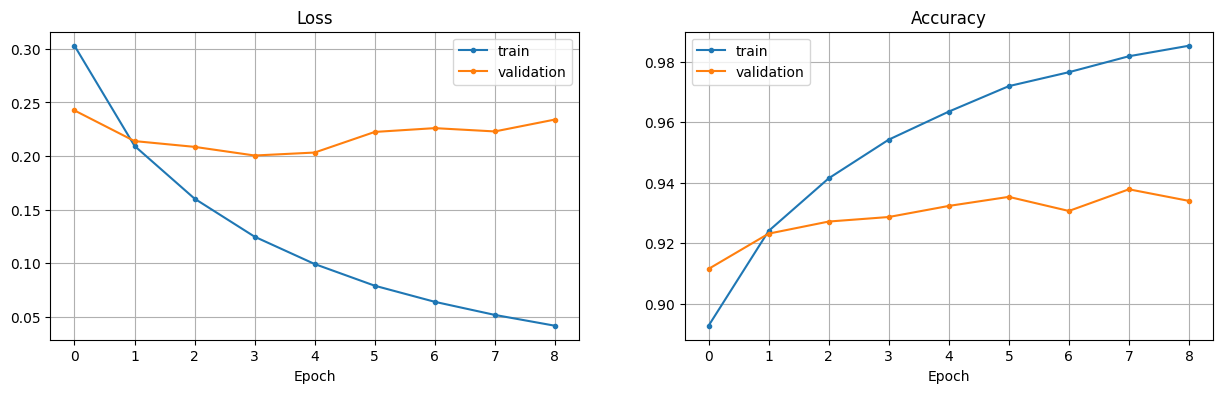

In [ ]:
plot_loss_acc_per_ep(history.history["loss"],     history.history["val_loss"],
                     history.history["accuracy"], history.history["val_accuracy"])

In [ ]:
def build_rand_search_model(hp, epochs):
    name = hp.Choice("scheduler", [
            "constant",          # baseline: flat 1e-5, for comparison
            "custom_stairs",     # custom staircase
            "exponential",       # smooth *0.9 per epoch
            "cosine",            # glide 0.0006 -> ~0 over the whole run
            "cosine_restarts",   # cosine, but periodically jumps back up (escapes basins)
            "inverse_time",      # 1/(1+decay*t)
            "piecewise",         # gentler staircase: /10 at epoch 10, /100 at 15
        ])

    base  = 1e-5
    steps = len(train_loader)          # batches per epoch
    S     = keras.optimizers.schedules

    if name == "custom_stairs":
        lr = S.PiecewiseConstantDecay(boundaries=[steps * 4, steps * 7, steps * 10],
                                      values=[base, 1e-6, 1e-7, 1e-8])
    elif name == "exponential":
        lr = S.ExponentialDecay(base, decay_steps=steps, decay_rate=0.9)
    elif name == "cosine":
        lr = S.CosineDecay(base, decay_steps=steps * epochs)
    elif name == "cosine_restarts":
        lr = S.CosineDecayRestarts(base, first_decay_steps=steps * 10)
    elif name == "inverse_time":
        lr = S.InverseTimeDecay(base, decay_steps=steps, decay_rate=0.5)
    elif name == "piecewise":
        lr = S.PiecewiseConstantDecay(boundaries=[steps * 10, steps * 15],
                                      values=[base, base * 0.1, base * 0.01])
    else: # "constant"
        lr = base

    keras.utils.set_random_seed(RANDOM_SEED)
    torch_gen.manual_seed(RANDOM_SEED)
    # Reset seeds and clear previous Keras/PyTorch GPU state
    keras.backend.clear_session()
    gc.collect()
    torch.cuda.empty_cache()

    # 2. Re-instantiate a FRESH base model from ImageNet weights
    fresh_base = keras.applications.VGG16(
        weights="imagenet",                     # use pre-trained model
        include_top=False,                      # remove the head
        input_shape=(IMG_SIZE, IMG_SIZE, 3),    # expect the output as specified
    )
    fresh_base.trainable = False                      # freeze the base

    # Unfreeze Block 5 on the new base instance
    fresh_base.trainable = True
    for layer in fresh_base.layers[:-4]:
        layer.trainable = False

    # 2. Build the FULL end-to-end model
    inputs = keras.Input(shape=(28, 28))

    # Preprocessing (identical to your extractor)
    x = keras.layers.Reshape((28, 28, 1))(inputs)
    x = keras.layers.Lambda(lambda t: keras.ops.repeat(t, 3, axis=-1))(x)
    x = keras.layers.Resizing(IMG_SIZE, IMG_SIZE, interpolation="bilinear")(x)
    x = keras.layers.Lambda(keras.applications.vgg16.preprocess_input)(x)

    # Pass through the partially trainable base
    x = fresh_base(x)
    x = keras.layers.GlobalAveragePooling2D()(x)

    # Add your tuned head
    x = keras.layers.Dropout(0.2, seed=RANDOM_SEED)(x)
    outputs = keras.layers.Dense(10, activation="softmax")(x)

    model = keras.Model(inputs, outputs)
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=lr),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )
    return model

In [ ]:
keras.utils.set_random_seed(RANDOM_SEED)
torch_gen.manual_seed(RANDOM_SEED)
train_loader, valid_loader = build_loaders(batch_size=16, shuffle=True, generator=torch_gen)

sched_tuner = kt.GridSearch(
    functools.partial(build_rand_search_model, epochs=30),   # more epochs + functools to send an additional argument
    objective="val_accuracy",
    directory="task_2_fine_tuning_lr_schedulers",
    project_name="fashion_mnist_schedulers",
    seed=RANDOM_SEED,
    overwrite=True, # start a new search
)
sched_tuner.search(x=train_loader, validation_data=valid_loader, epochs=30,
                   callbacks=[keras.callbacks.EarlyStopping(monitor="val_loss", patience=5,
                                                            restore_best_weights=True, verbose=1)],
                   verbose=1, shuffle=False)

Trial 7 Complete [00h 28m 10s]
val_accuracy: 0.9380000233650208

Best val_accuracy So Far: 0.9380000233650208
Total elapsed time: 03h 27m 08s


In [ ]:
debug_tuner(sched_tuner)

,trial_id,score,scheduler
0,0000,0.938000,constant
6,0006,0.938000,piecewise
3,0003,0.937167,cosine
2,0002,0.936167,exponential
1,0001,0.935333,custom_stairs
4,0004,0.935333,cosine_restarts
5,0005,0.933167,inverse_time


In [ ]:
def build_model(base):
  # 1. Unfreeze the top 4 layers of the base (Block 5)
  base.trainable = True
  for layer in base.layers[:-4]:
      layer.trainable = False

  # 2. Build the FULL end-to-end model
  inputs = keras.Input(shape=(28, 28))

  # Preprocessing (identical to your extractor)
  x = keras.layers.Reshape((28, 28, 1))(inputs)
  x = keras.layers.Lambda(lambda t: keras.ops.repeat(t, 3, axis=-1))(x)
  x = keras.layers.Resizing(IMG_SIZE, IMG_SIZE, interpolation="bilinear")(x)
  x = keras.layers.Lambda(keras.applications.vgg16.preprocess_input)(x)

  # Pass through the partially trainable base
  x = base(x)
  x = keras.layers.GlobalAveragePooling2D()(x)

  # Add your tuned head
  x = keras.layers.Dropout(0.2, seed=RANDOM_SEED)(x)
  outputs = keras.layers.Dense(10, activation="softmax")(x)

  model = keras.Model(inputs, outputs)
  return model


keras.utils.set_random_seed(RANDOM_SEED)
torch_gen.manual_seed(RANDOM_SEED)
# Reset seeds and clear previous Keras/PyTorch GPU state
keras.backend.clear_session()
gc.collect()
torch.cuda.empty_cache()

# 2. Re-instantiate a FRESH base model from ImageNet weights
fresh_base = keras.applications.VGG16(
    weights="imagenet",                     # use pre-trained model
    include_top=False,                      # remove the head
    input_shape=(IMG_SIZE, IMG_SIZE, 3),    # expect the output as specified
)
fresh_base.trainable = False                      # freeze the base


# Smaller batch size is needed here; backpropagating through VGG Block 5 uses much more VRAM, it crashes
train_loader, valid_loader = build_loaders(batch_size=16, shuffle=True, generator=torch_gen)

model = build_model(fresh_base)

# 3. Compile the end-to-end model
model.compile(
    optimizer=keras.optimizers.Adam(1e-5),     # Microscopic LR to prevent wrecking the pretrained weights
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)

history = model.fit(
    x=train_loader,
    validation_data=valid_loader,
    epochs=20,
    callbacks=[
        keras.callbacks.EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True, verbose=1),
    ],
    verbose=1,
    shuffle=False,
)

Epoch 1/20
3375/3375 ━━━━━━━━━━━━━━━━━━━━ 167s 49ms/step - accuracy: 0.8408 - loss: 0.5164 - val_accuracy: 0.9077 - val_loss: 0.2613
Epoch 2/20
3375/3375 ━━━━━━━━━━━━━━━━━━━━ 166s 49ms/step - accuracy: 0.9170 - loss: 0.2348 - val_accuracy: 0.9232 - val_loss: 0.2204
Epoch 3/20
3375/3375 ━━━━━━━━━━━━━━━━━━━━ 166s 49ms/step - accuracy: 0.9366 - loss: 0.1773 - val_accuracy: 0.9258 - val_loss: 0.2144
Epoch 4/20
3375/3375 ━━━━━━━━━━━━━━━━━━━━ 167s 49ms/step - accuracy: 0.9491 - loss: 0.1414 - val_accuracy: 0.9258 - val_loss: 0.2097
Epoch 5/20
3375/3375 ━━━━━━━━━━━━━━━━━━━━ 166s 49ms/step - accuracy: 0.9590 - loss: 0.1116 - val_accuracy: 0.9380 - val_loss: 0.1949
Epoch 6/20
3375/3375 ━━━━━━━━━━━━━━━━━━━━ 165s 49ms/step - accuracy: 0.9689 - loss: 0.0875 - val_accuracy: 0.9312 - val_loss: 0.2153
Epoch 7/20
3375/3375 ━━━━━━━━━━━━━━━━━━━━ 166s 49ms/step - accuracy: 0.9740 - loss: 0.0723 - val_accuracy: 0.9328 - val_loss: 0.2324
Epoch 8/20
3375/3375 ━━━━━━━━━━━━━━━━━━━━ 166s 49ms/step - accuracy: 

Smoothed scores over epochs grouped by folds:
Epoch  0: train_loss=0.5164  val_loss=0.2613  train_acc=0.8408  val_acc=0.9077
Epoch  1: train_loss=0.2348  val_loss=0.2204  train_acc=0.9170  val_acc=0.9232
Epoch  2: train_loss=0.1773  val_loss=0.2144  train_acc=0.9366  val_acc=0.9258
Epoch  3: train_loss=0.1414  val_loss=0.2097  train_acc=0.9491  val_acc=0.9258
Epoch  4: train_loss=0.1116  val_loss=0.1949  train_acc=0.9590  val_acc=0.9380
Epoch  5: train_loss=0.0875  val_loss=0.2153  train_acc=0.9689  val_acc=0.9312
Epoch  6: train_loss=0.0723  val_loss=0.2324  train_acc=0.9740  val_acc=0.9328
Epoch  7: train_loss=0.0580  val_loss=0.2194  train_acc=0.9789  val_acc=0.9363
Epoch  8: train_loss=0.0474  val_loss=0.2224  train_acc=0.9835  val_acc=0.9348
Epoch  9: train_loss=0.0389  val_loss=0.2091  train_acc=0.9868  val_acc=0.9360



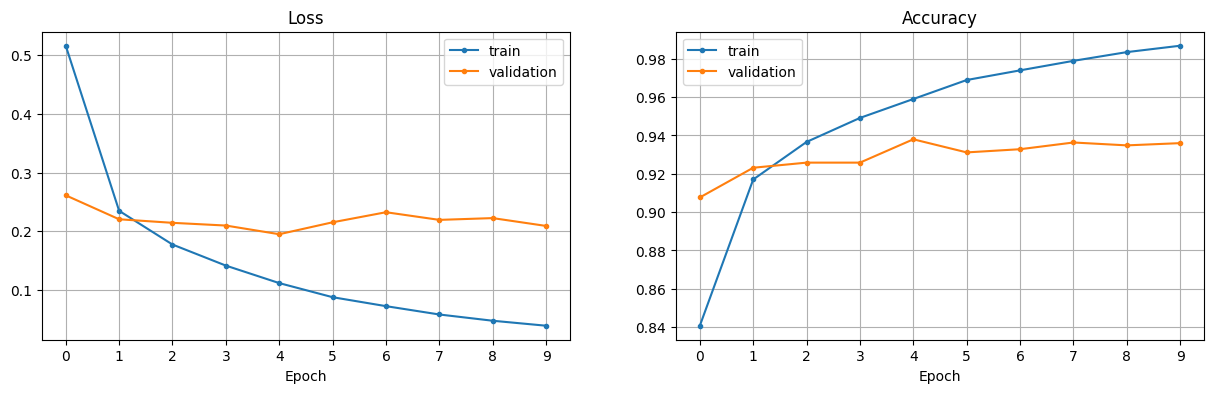

In [ ]:
plot_loss_acc_per_ep(history.history["loss"],     history.history["val_loss"],
                     history.history["accuracy"], history.history["val_accuracy"])

5th epoch is best, fitting on full train

In [ ]:
keras.utils.set_random_seed(RANDOM_SEED)
torch_gen.manual_seed(RANDOM_SEED)
# Reset seeds and clear previous Keras/PyTorch GPU state
keras.backend.clear_session()
gc.collect()
torch.cuda.empty_cache()

# 2. Re-instantiate a FRESH base model from ImageNet weights
fresh_base = keras.applications.VGG16(
    weights="imagenet",                     # use pre-trained model
    include_top=False,                      # remove the head
    input_shape=(IMG_SIZE, IMG_SIZE, 3),    # expect the output as specified
)
fresh_base.trainable = False                      # freeze the base


full_train_loader = DataLoader(full_train_ds, batch_size=16, shuffle=True, generator=torch_gen)
steps = len(full_train_loader)          # batches per epoch (for lr scheduler)

model = build_model(fresh_base)

# 3. Compile the end-to-end model
model.compile(
    optimizer=keras.optimizers.Adam(1e-5),     # Microscopic LR to prevent wrecking the pretrained weights
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)


history = model.fit(
    x=full_train_loader,
    epochs=5,
    verbose=1,
    shuffle=False,
)

Epoch 1/5
3750/3750 ━━━━━━━━━━━━━━━━━━━━ 172s 46ms/step - accuracy: 0.8458 - loss: 0.5003
Epoch 2/5
3750/3750 ━━━━━━━━━━━━━━━━━━━━ 171s 46ms/step - accuracy: 0.9179 - loss: 0.2283
Epoch 3/5
3750/3750 ━━━━━━━━━━━━━━━━━━━━ 171s 46ms/step - accuracy: 0.9368 - loss: 0.1753
Epoch 4/5
3750/3750 ━━━━━━━━━━━━━━━━━━━━ 171s 45ms/step - accuracy: 0.9493 - loss: 0.1391
Epoch 5/5
3750/3750 ━━━━━━━━━━━━━━━━━━━━ 171s 46ms/step - accuracy: 0.9597 - loss: 0.1103


Smoothed scores over epochs grouped by folds:



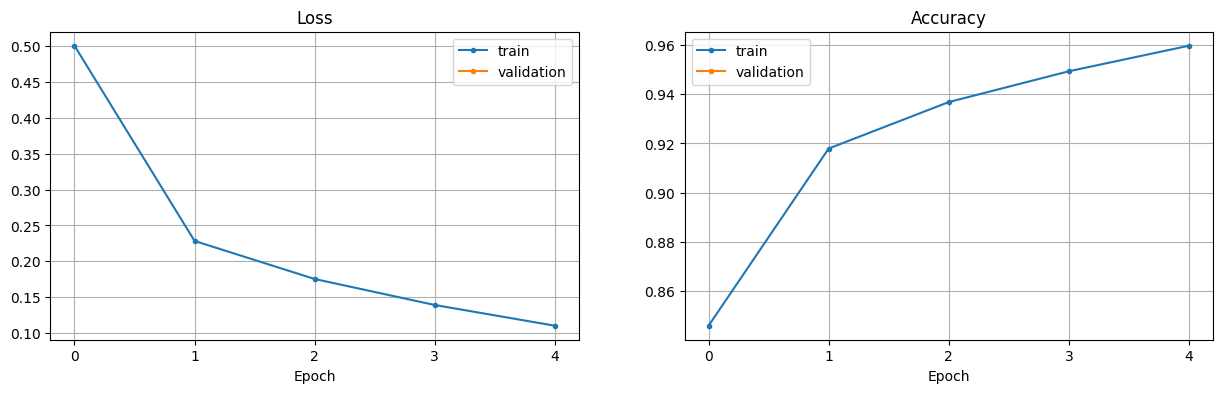

In [ ]:
plot_loss_acc_per_ep(history.history["loss"],     [],
                     history.history["accuracy"], [])

In [ ]:
test_loader = DataLoader(test_ds, batch_size=16, shuffle=False)
test_loss, test_acc = model.evaluate(test_loader, verbose=1)

print("\n" + "="*40)
print(f"FINAL TEST ACCURACY: {test_acc * 100:.2f}%")
print(f"FINAL TEST LOSS:     {test_loss:.4f}")
print("="*40)

625/625 ━━━━━━━━━━━━━━━━━━━━ 21s 34ms/step - accuracy: 0.9335 - loss: 0.1942

FINAL TEST ACCURACY: 93.35%
FINAL TEST LOSS:     0.1942


In [ ]:
# --- Save (Keras 3 native: architecture + weights + optimizer state in one file) ---
model.save("fashion_mnist_final_test_task2.keras")

# --- Load ---
loaded = keras.models.load_model("fashion_mnist_final_test_task2.keras", safe_mode=False)

              precision    recall  f1-score   support

 T-shirt/top     0.8677    0.9120    0.8893      1000
     Trouser     0.9980    0.9860    0.9920      1000
    Pullover     0.8851    0.9170    0.9008      1000
       Dress     0.9140    0.9460    0.9297      1000
        Coat     0.9255    0.8700    0.8969      1000
      Sandal     0.9929    0.9780    0.9854      1000
       Shirt     0.8197    0.7730    0.7957      1000
     Sneaker     0.9628    0.9840    0.9733      1000
         Bag     0.9901    0.9970    0.9935      1000
  Ankle boot     0.9789    0.9720    0.9754      1000

    accuracy                         0.9335     10000
   macro avg     0.9335    0.9335    0.9332     10000
weighted avg     0.9335    0.9335    0.9332     10000



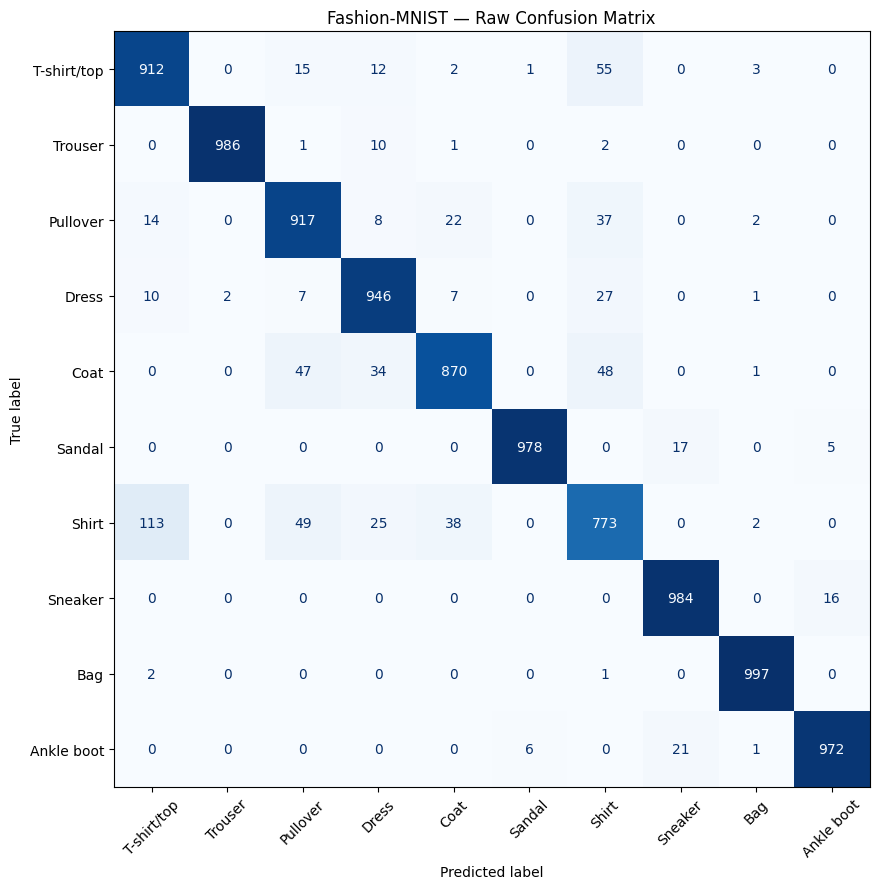

In [ ]:
CLASS_NAMES = ["T-shirt/top", "Trouser", "Pullover", "Dress", "Coat",
               "Sandal", "Shirt", "Sneaker", "Bag", "Ankle boot"]

# --- 1. Predictions + true labels out of the DataLoader ---
y_prob = model.predict(test_loader, verbose=0)          # (10000, 10) softmax probabilities
y_pred = y_prob.argmax(axis=1)                          # most probable class indices
y_true = np.concatenate([yb.numpy() for _, yb in test_loader])  # convert each y_batch from tensor to numpy and concatenate into 1D array

# --- 2. Per-class metrics ---
print(classification_report(y_true, y_pred, target_names=CLASS_NAMES, digits=4))

# --- 3. Confusion matrix ---
cm = confusion_matrix(y_true, y_pred)

fig, ax = plt.subplots(figsize=(9, 9))
ConfusionMatrixDisplay(cm, display_labels=CLASS_NAMES).plot(
    ax=ax,
    cmap="Blues",
    colorbar=False,
    values_format="d",  # integer format
    xticks_rotation=45,
)
ax.set_title("Fashion-MNIST — Raw Confusion Matrix")
plt.tight_layout()
plt.show()